# Monthly Behavioral Perspective
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

Monthly Behavioral segmentation, analyzing purchasing habits and travel behaviors

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#1st-bullet)<br>

[**Data Preposessing**](#2nd-bullet)<br>

    
</div>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import umap
import warnings

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import silhouette_score, silhouette_samples # new library
from sklearn.cluster import KMeans # new library
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_context("notebook")
sns.set_style("ticks")

In [2]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

# By Month

In [3]:
M_Behavioral_columns = df_AIAI_Master.columns.to_list()[-48:]

df_AIAI_M_Behavioral = df_AIAI_Master[M_Behavioral_columns].copy()
df_AIAI_M_Behavioral.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610
549612,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500
429460,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.0000,6.1044,0.0000,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556
608370,11.0,21.0,31.0,13.0,24.0,37.0,0.0,0.0,19.0,22.0,2.0,16.0,49255.0,35206.0,65665.0,37464.0,38224.0,45139.0,0.0,0.0,9285.0,53130.0,29241.0,23421.0,72.727273,52.380952,41.935484,0.000000,16.666667,0.000000,0.0,0.000000,10.526316,59.090909,0.000000,43.750000,-13.7374,-31.4985,65.6521,37.4562,38.2229,45.1288,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270
530508,0.0,22.0,4.0,0.0,24.0,15.0,21.0,38.0,8.0,0.0,24.0,15.0,0.0,19731.0,5566.0,0.0,47106.0,54063.0,55404.0,73431.0,68327.0,0.0,40863.0,2122.0,0.000000,40.909091,100.000000,0.000000,25.000000,60.000000,0.0,34.210526,100.000000,0.000000,41.666667,26.666667,0.0000,19.7142,5.5600,0.0000,47.0977,54.0565,55.3928,73.4215,68.3248,0.0000,40.8525,2.1200


In [4]:
df_AIAI_M_Behavioral.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 48 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Total_NumFlights_month_1               15101 non-null  float64
 1   Total_NumFlights_month_2               15101 non-null  float64
 2   Total_NumFlights_month_3               15101 non-null  float64
 3   Total_NumFlights_month_4               15101 non-null  float64
 4   Total_NumFlights_month_5               15101 non-null  float64
 5   Total_NumFlights_month_6               15101 non-null  float64
 6   Total_NumFlights_month_7               15101 non-null  float64
 7   Total_NumFlights_month_8               15101 non-null  float64
 8   Total_NumFlights_month_9               15101 non-null  float64
 9   Total_NumFlights_month_10              15101 non-null  float64
 10  Total_NumFlights_month_11              15101 non-null  float64
 11  T

In [5]:
df_AIAI_M_Behavioral.isna().sum()

Total_NumFlights_month_1                 1471
Total_NumFlights_month_2                 1471
Total_NumFlights_month_3                 1471
Total_NumFlights_month_4                 1471
Total_NumFlights_month_5                 1471
Total_NumFlights_month_6                 1471
Total_NumFlights_month_7                 1471
Total_NumFlights_month_8                 1471
Total_NumFlights_month_9                 1471
Total_NumFlights_month_10                1471
Total_NumFlights_month_11                1471
Total_NumFlights_month_12                1471
Total_DistanceKM_month_1                 1471
Total_DistanceKM_month_2                 1471
Total_DistanceKM_month_3                 1471
Total_DistanceKM_month_4                 1471
Total_DistanceKM_month_5                 1471
Total_DistanceKM_month_6                 1471
Total_DistanceKM_month_7                 1471
Total_DistanceKM_month_8                 1471
Total_DistanceKM_month_9                 1471
Total_DistanceKM_month_10         

In [6]:
# Filter rows with any missing values into a new dataframe and add No_transactions (count of missing per row)
df_AIAI_M_Behavioral_classified = df_AIAI_M_Behavioral[df_AIAI_M_Behavioral.isna().any(axis=1)].copy()
df_AIAI_M_Behavioral_classified['Final_Cluster'] = 'No_transactions'

# Remove those observations from the original dataframe
df_AIAI_M_Behavioral = df_AIAI_M_Behavioral.drop(df_AIAI_M_Behavioral_classified.index)

df_AIAI_M_Behavioral_classified.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Final_Cluster
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
201574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
834891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
329382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
357549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
283314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions


In [7]:
df_AIAI_M_Behavioral.isna().sum()

Total_NumFlights_month_1                 0
Total_NumFlights_month_2                 0
Total_NumFlights_month_3                 0
Total_NumFlights_month_4                 0
Total_NumFlights_month_5                 0
Total_NumFlights_month_6                 0
Total_NumFlights_month_7                 0
Total_NumFlights_month_8                 0
Total_NumFlights_month_9                 0
Total_NumFlights_month_10                0
Total_NumFlights_month_11                0
Total_NumFlights_month_12                0
Total_DistanceKM_month_1                 0
Total_DistanceKM_month_2                 0
Total_DistanceKM_month_3                 0
Total_DistanceKM_month_4                 0
Total_DistanceKM_month_5                 0
Total_DistanceKM_month_6                 0
Total_DistanceKM_month_7                 0
Total_DistanceKM_month_8                 0
Total_DistanceKM_month_9                 0
Total_DistanceKM_month_10                0
Total_DistanceKM_month_11                0
Total_Dista

# Outliers Vizualizations

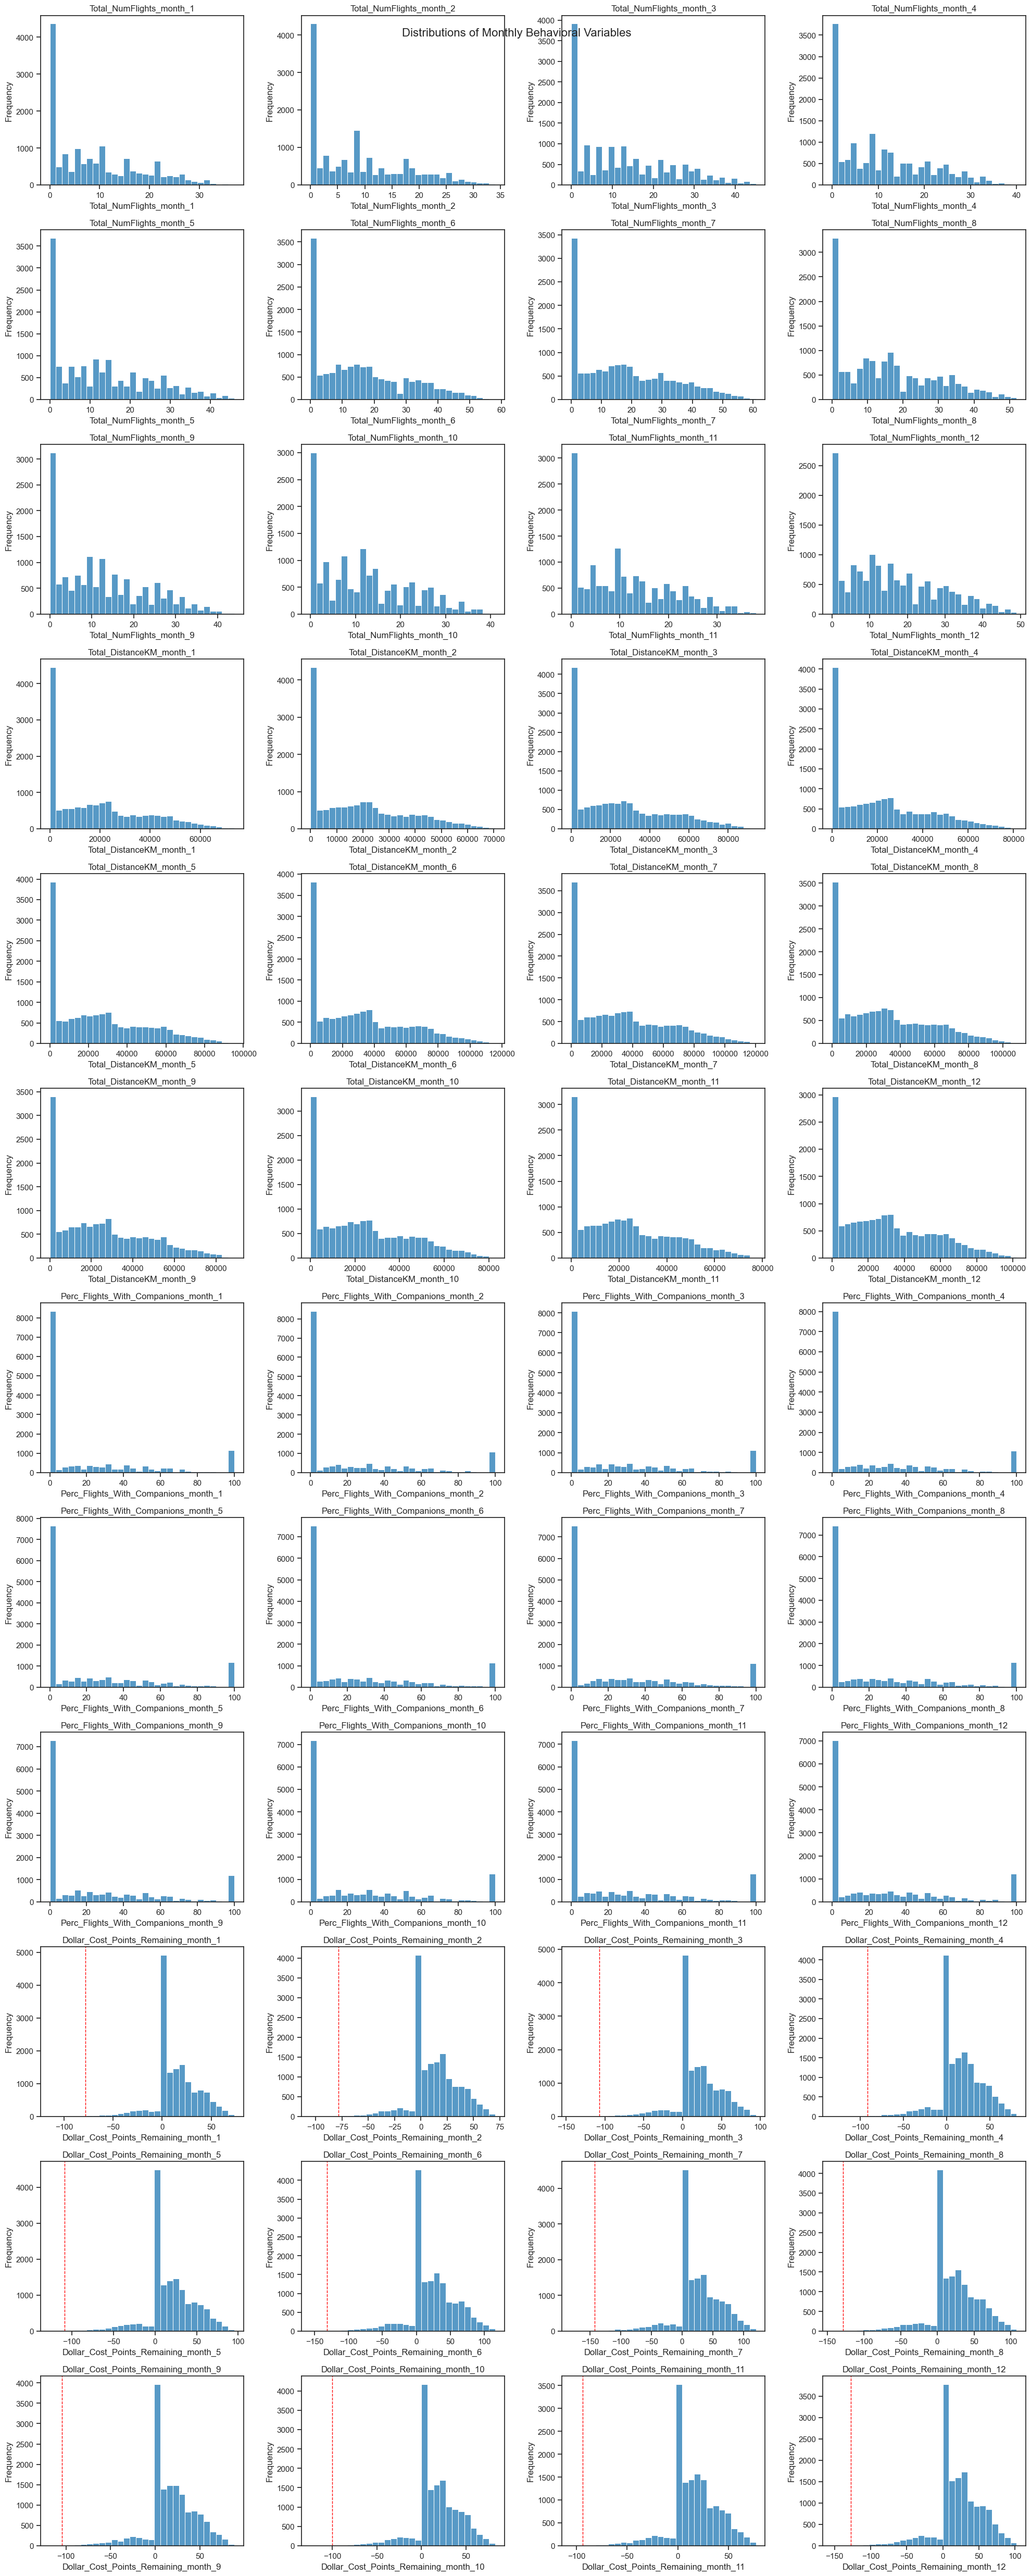

In [8]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Monthly Behavioral Variables", fontsize=16)
plt.tight_layout()
plt.show()

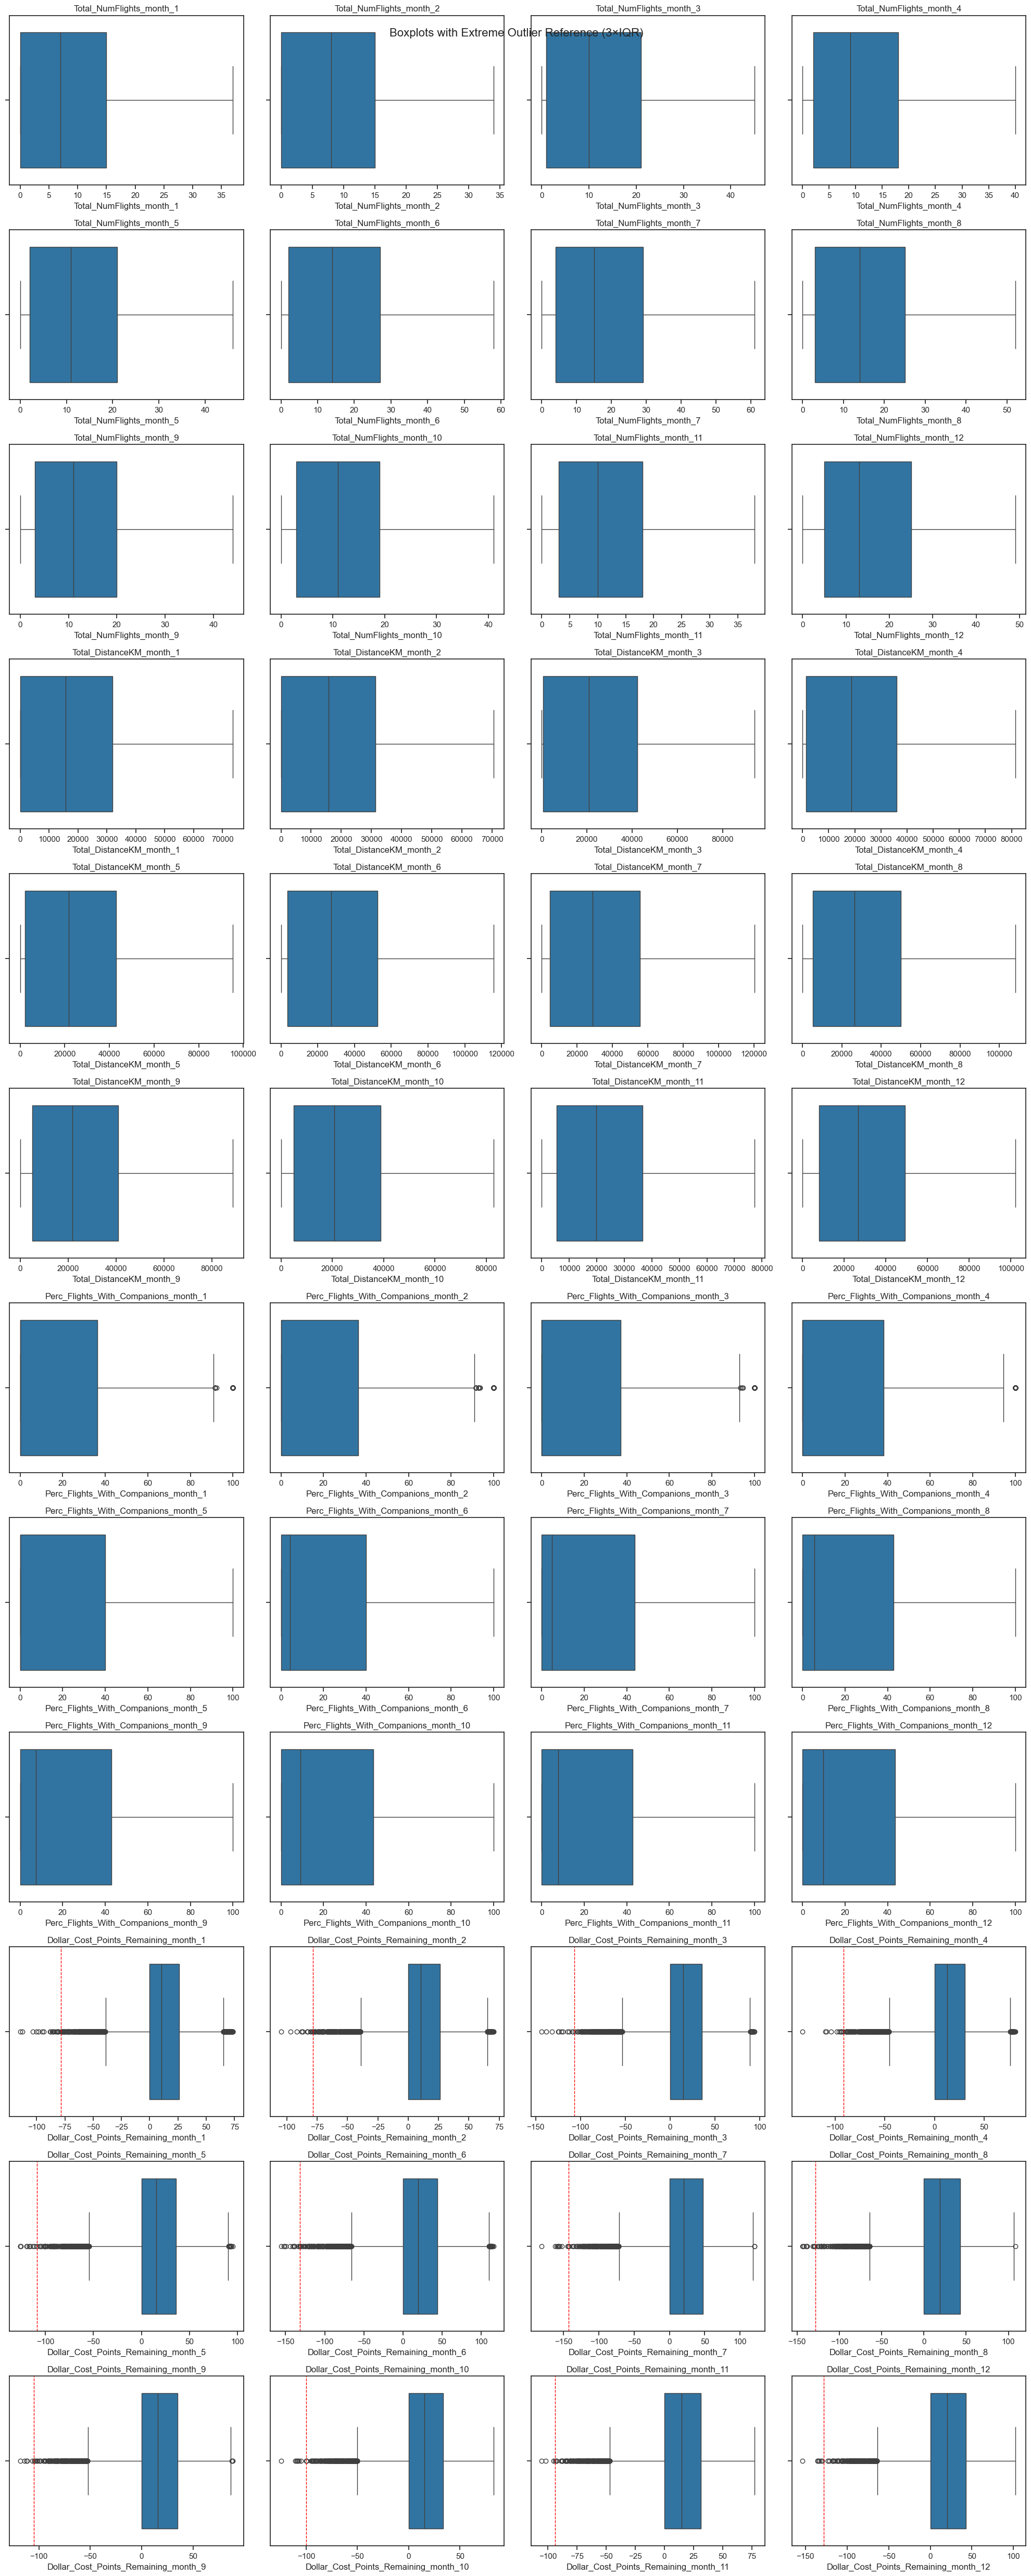

In [9]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [10]:
q1 = df_AIAI_M_Behavioral.quantile(0.25)
q3 = df_AIAI_M_Behavioral.quantile(0.75)
iqr = q3 - q1
lower_extreme = q1 - 3 * iqr
upper_extreme = q3 + 3 * iqr

# Cap values to the extreme bounds
df_AIAI_M_Behavioral = df_AIAI_M_Behavioral.copy()
for col in df_AIAI_M_Behavioral.columns:
    df_AIAI_M_Behavioral[col] = df_AIAI_M_Behavioral[col].clip(lower=lower_extreme[col], upper=upper_extreme[col])


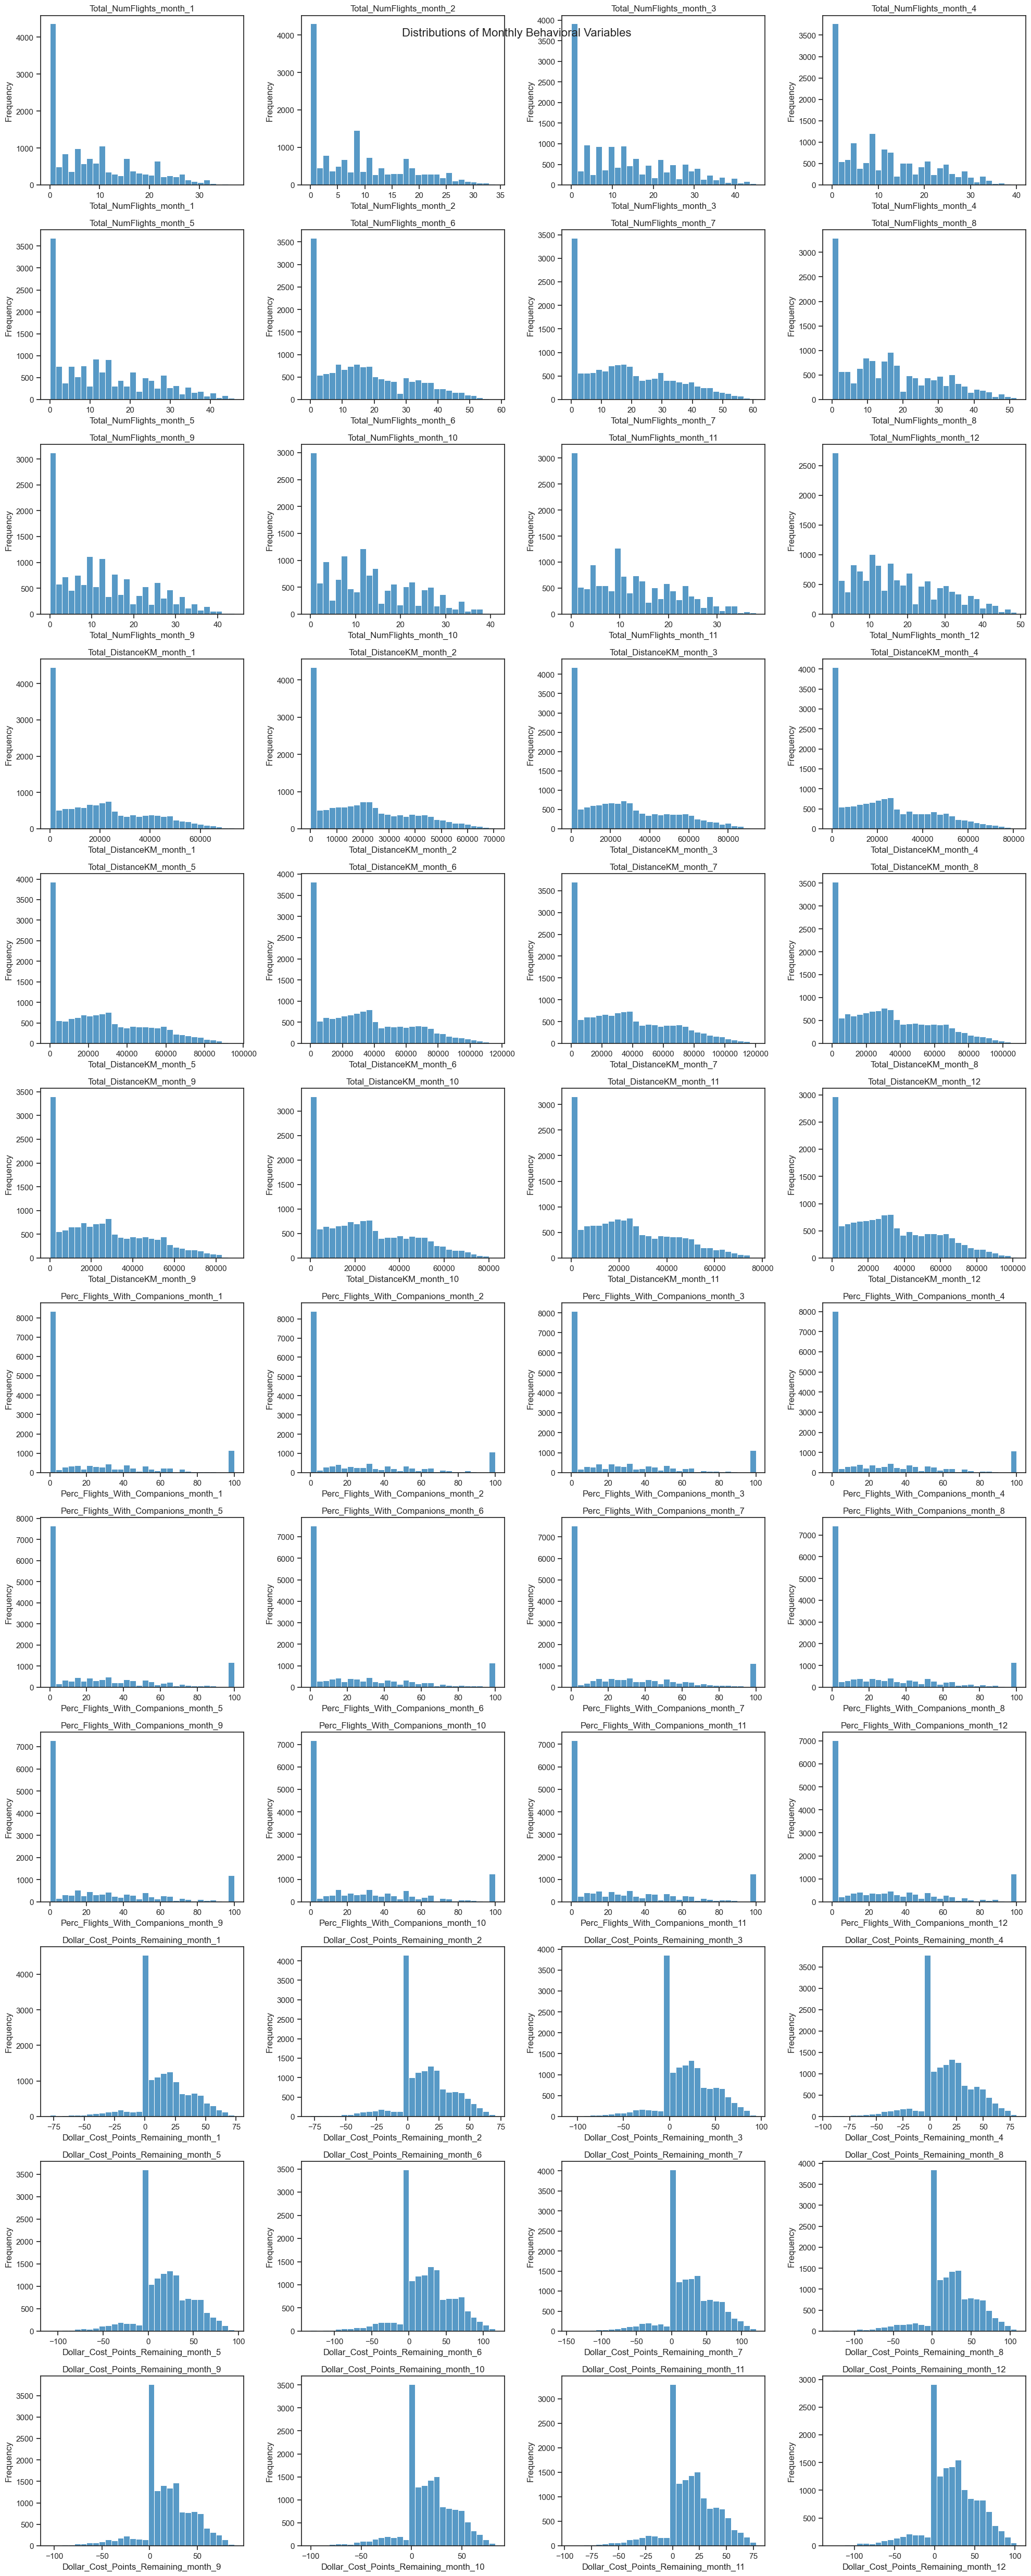

In [11]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Monthly Behavioral Variables", fontsize=16)
plt.tight_layout()
plt.show()

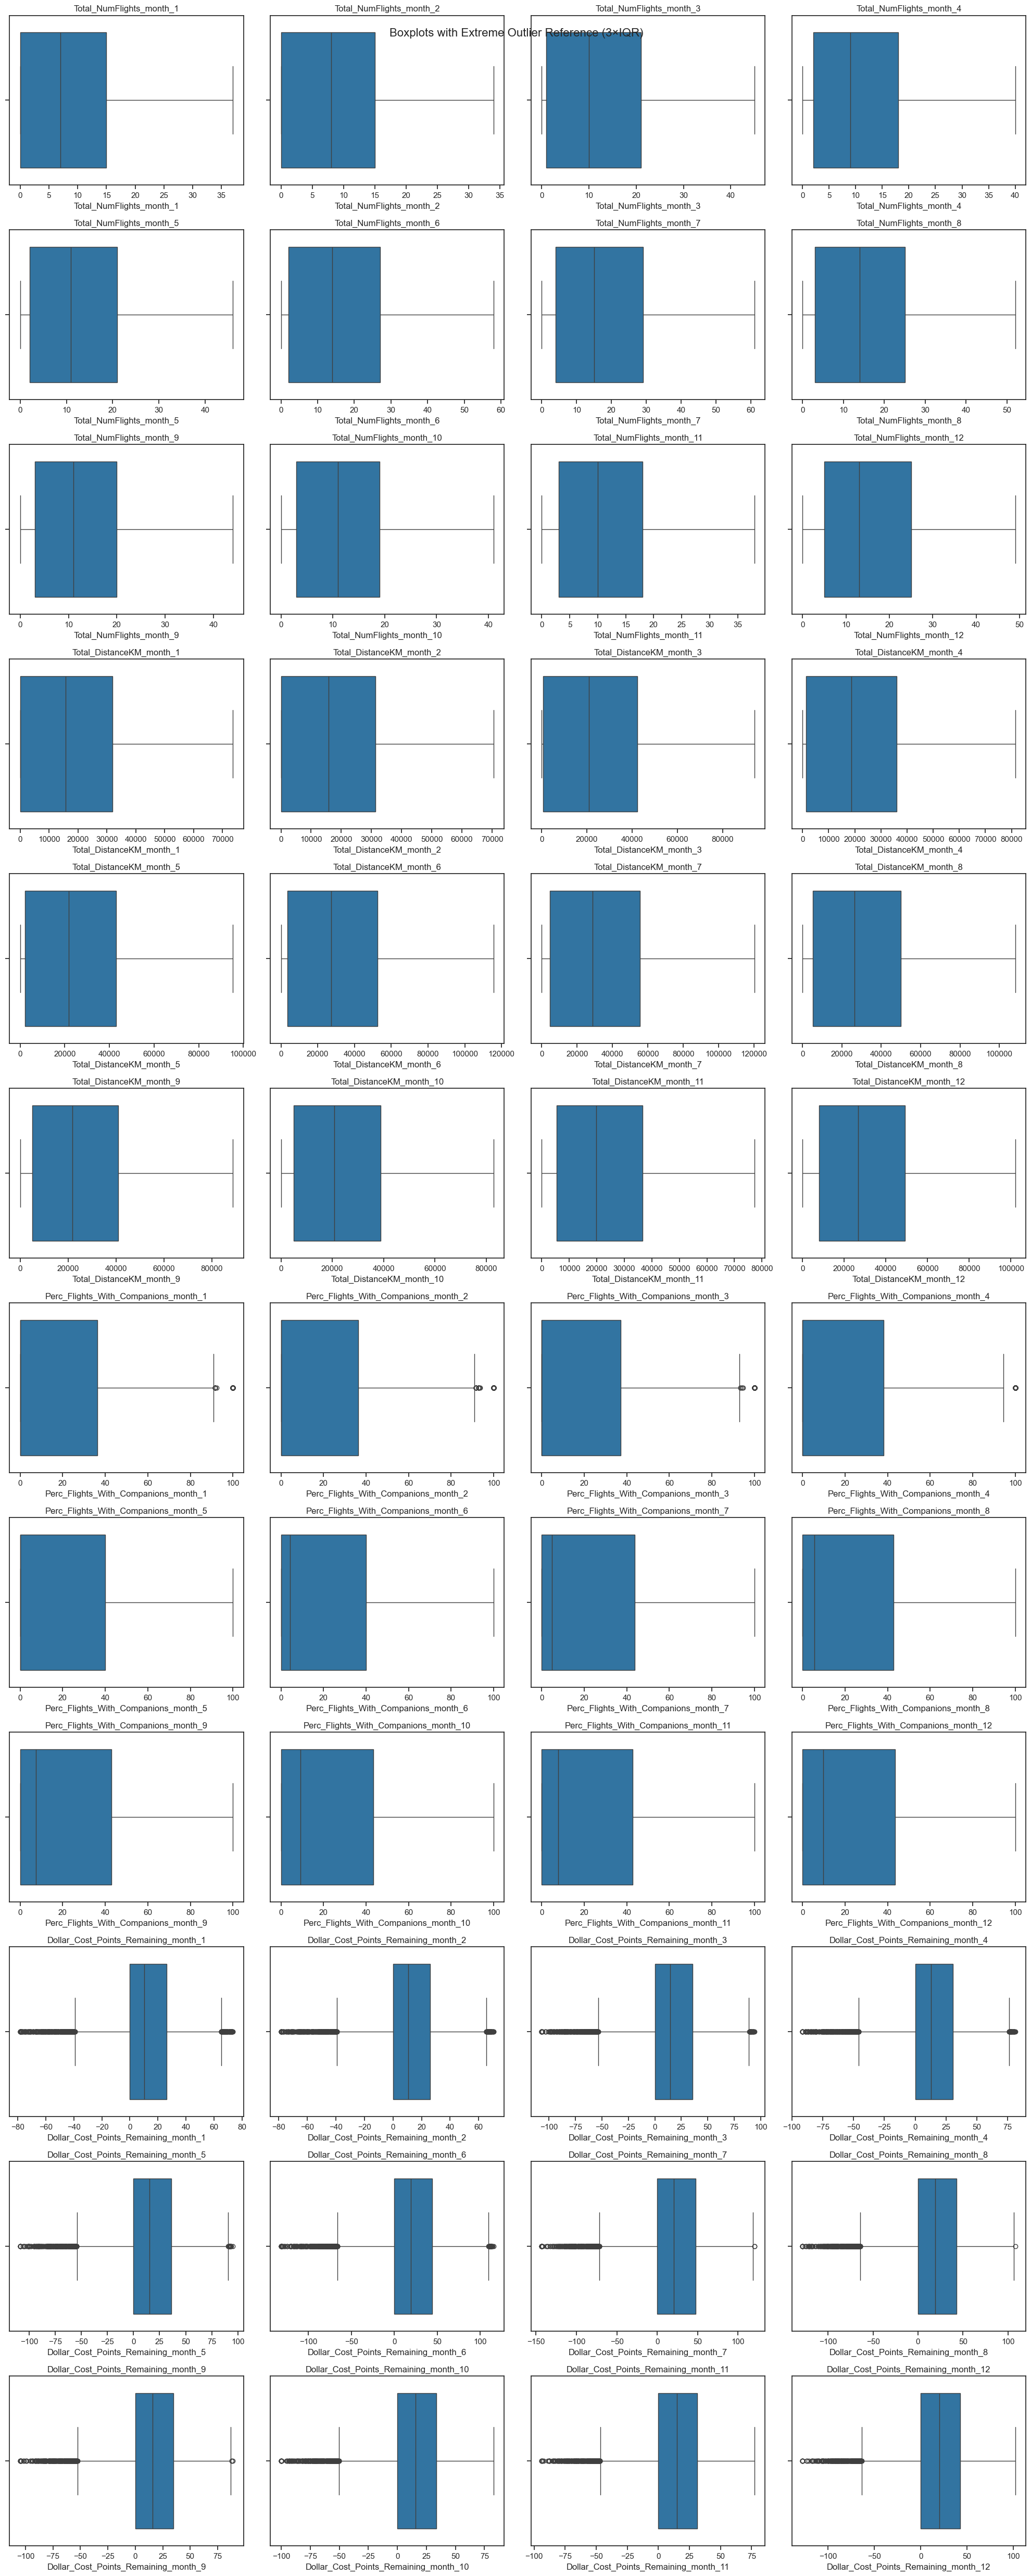

In [12]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

Scale

In [13]:
scaler = MinMaxScaler(feature_range= (-1,1) )
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_AIAI_M_Behavioral),
    index=df_AIAI_M_Behavioral.index,
    columns=df_AIAI_M_Behavioral.columns
)

In [14]:
df_for_modeling.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,-0.891892,-0.529412,-0.911111,-0.35,0.391304,-0.172414,-0.016393,0.192308,-0.227273,-0.609756,-0.210526,-0.632653,-0.315672,0.857947,-0.738060,-0.881069,0.451549,-0.241395,-0.173170,-0.168358,0.002735,0.712493,-0.450050,-0.117143,-1.000000,-0.500000,1.000000,-0.538462,-0.375000,-1.000000,-1.0,-0.290323,0.176471,0.000000,0.466667,-0.333333,0.362942,0.933138,0.186312,0.115698,0.743965,0.419770,0.463930,0.466234,0.542396,0.464049,-0.187678,0.047650
549612,0.297297,0.000000,0.422222,-0.50,0.826087,-0.586207,0.180328,0.384615,-0.545455,0.365854,0.105263,-0.551020,-0.287835,-0.258960,-0.388021,-0.755308,0.216922,-0.946818,-0.335845,0.420826,-0.452429,-0.186522,-0.070931,-0.468064,-0.500000,-1.000000,-1.000000,-0.400000,-1.000000,-0.166667,-0.5,-0.500000,-1.000000,-1.000000,-1.000000,-1.000000,0.022980,0.404176,0.350153,0.174948,0.634326,0.090104,-1.000000,0.735342,0.333519,0.462776,0.516518,0.347975
429460,0.135135,-0.529412,-0.333333,-1.00,0.000000,-1.000000,-1.000000,-0.192308,-0.318182,-1.000000,-0.210526,-0.918367,0.814979,-0.827058,-0.354800,-1.000000,-0.871819,-1.000000,-1.000000,-0.687635,0.279120,-1.000000,-0.973336,-0.103448,-1.000000,0.500000,0.733333,-1.000000,-0.826087,-1.000000,-1.0,0.619048,-1.000000,-1.000000,-1.000000,1.000000,0.910469,-0.601283,0.365727,0.059578,0.125869,0.065304,0.086147,0.229050,0.669214,0.094675,0.109210,0.509886
608370,-0.405405,0.235294,0.377778,-0.35,0.043478,0.275862,-1.000000,-1.000000,-0.136364,0.073171,-0.894737,-0.346939,0.338997,-0.001376,0.395673,-0.079418,-0.198104,-0.219825,-1.000000,-1.000000,-0.790989,0.282342,-0.243030,-0.541125,0.454545,0.047619,-0.161290,-1.000000,-0.666667,-1.000000,-1.0,-1.000000,-0.789474,0.181818,-1.000000,-0.125000,-0.149340,-0.370056,0.717038,0.493880,0.440563,0.429871,0.086147,0.086398,0.178134,0.675157,0.438929,0.022709
530508,-1.000000,0.294118,-0.822222,-1.00,0.043478,-0.482759,-0.311475,0.461538,-0.636364,-1.000000,0.263158,-0.387755,-1.000000,-0.440327,-0.881698,-1.000000,-0.011769,-0.065584,-0.078443,0.358764,0.538082,-1.000000,0.057832,-0.958425,-1.000000,-0.181818,1.000000,-1.000000,-0.500000,0.200000,-1.0,-0.315789,1.000000,-1.000000,-0.166667,-0.466667,0.031536,0.318040,0.119040,0.059578,0.527517,0.501992,0.507169,0.707008,0.788100,0.094675,0.574629,0.130157


In [15]:
df_for_modeling.describe()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
count,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000
mean,-0.505098,-0.465384,-0.450279,-0.467770,-0.428814,-0.446977,-0.414359,-0.397992,-0.426624,-0.415125,-0.405118,-0.372462,-0.479911,-0.464947,-0.462744,-0.460390,-0.456624,-0.450406,-0.440670,-0.436991,-0.434570,-0.425362,-0.412945,-0.404848,-0.572823,-0.573821,-0.564273,-0.559299,-0.533858,-0.530834,-0.507782,-0.515661,-0.508272,-0.496770,-0.508666,-0.492142,0.207437,0.229847,0.241166,0.235562,0.243045,0.243821,0.265667,0.265247,0.261347,0.276648,0.283462,0.295941
std,0.479096,0.505221,0.512471,0.487038,0.515396,0.494023,0.499234,0.515169,0.485600,0.488195,0.497011,0.507632,0.500496,0.507060,0.504546,0.497708,0.495828,0.495040,0.499527,0.493497,0.489115,0.492997,0.497009,0.492442,0.625233,0.625727,0.624228,0.623379,0.635101,0.635792,0.641423,0.643093,0.642386,0.644729,0.644597,0.644589,0.296956,0.293746,0.289493,0.292752,0.287995,0.290001,0.284778,0.286168,0.286892,0.283387,0.285717,0.283759
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,-0.955556,-0.900000,-0.913043,-0.931034,-0.868852,-0.884615,-0.863636,-0.853659,-0.842105,-0.795918,-1.000000,-1.000000,-0.986015,-0.967466,-0.954119,-0.939057,-0.922572,-0.903983,-0.887627,-0.879996,-0.859924,-0.844318,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.031536,0.053159,0.063711,0.059578,0.066059,0.065304,0.086147,0.086398,0.082287,0.094675,0.097198,0.111708
50%,

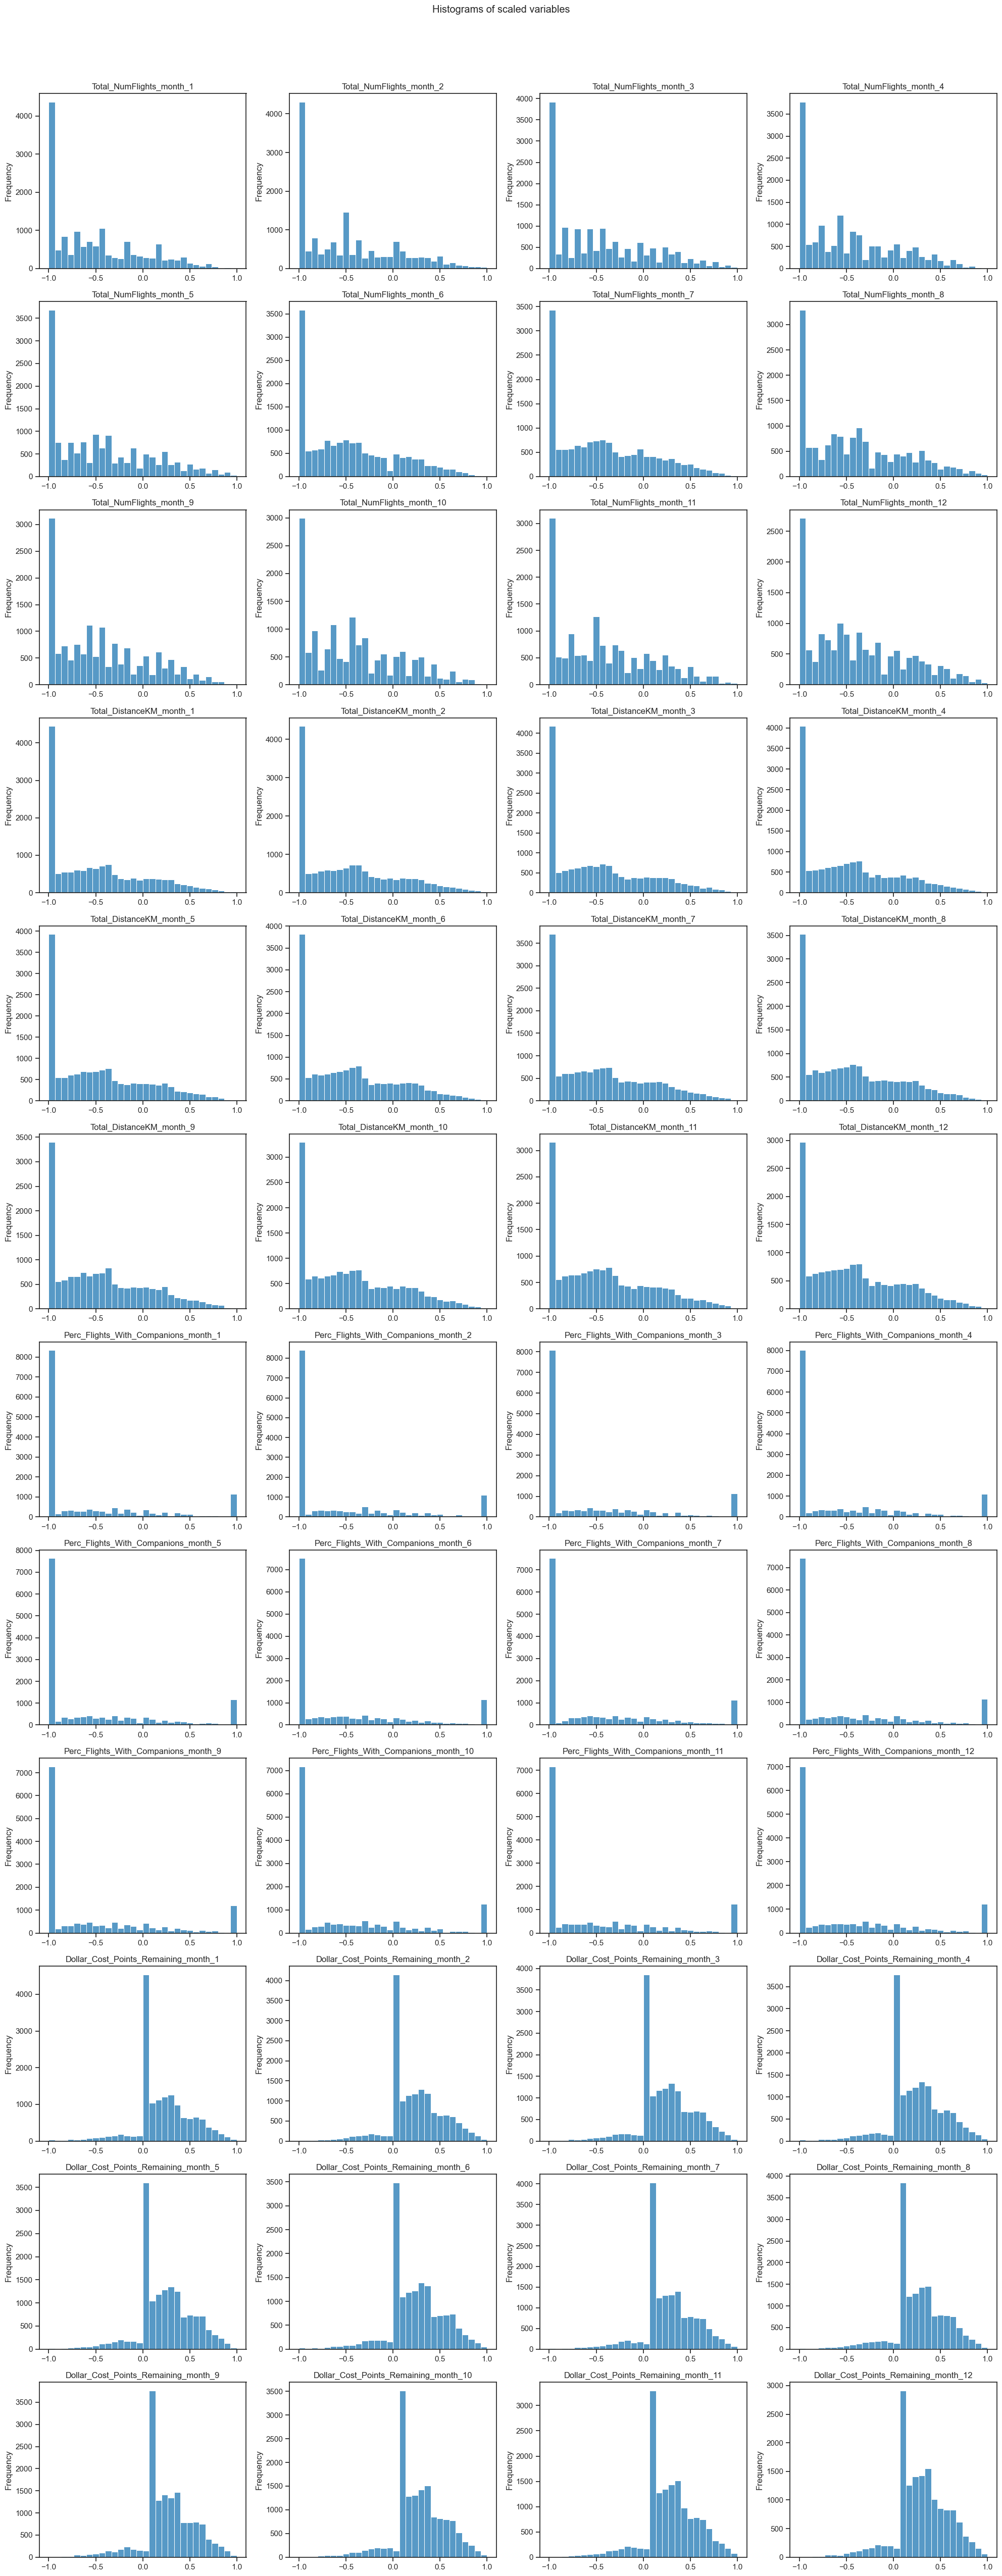

In [16]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_for_modeling.columns):
    sns.histplot(df_for_modeling[col].dropna(), bins=30, kde=False, ax=ax, color='C0')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.suptitle("Histograms of scaled variables", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
X = df_for_modeling.values

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 20):  # Test from 2 to 20 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(df_for_modeling)
    
    # ---- SSW ----
    ssw = kmclust.inertia_
    
    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)
    
    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)
    
    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,
        
        
    })

df_cluster_metrics = pd.DataFrame(results)
df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,157954.416473,20298.891099,0.098467,0.113877
1,3,154226.033412,24027.368733,0.072249,0.134793
2,4,151252.306388,27000.999851,0.074001,0.151475
3,5,148698.492596,29554.828274,0.075853,0.165802
4,6,146438.814111,31814.522334,0.075887,0.178479
5,7,144368.993938,33884.283045,0.076508,0.190091
6,8,142828.262785,35425.045787,0.057496,0.198734
7,9,141065.089205,37188.187778,0.049909,0.208626
8,10,139768.318228,38484.963327,0.046648,0.215900
9,11,138794.291586,39458.985397,0.034431,0.221365


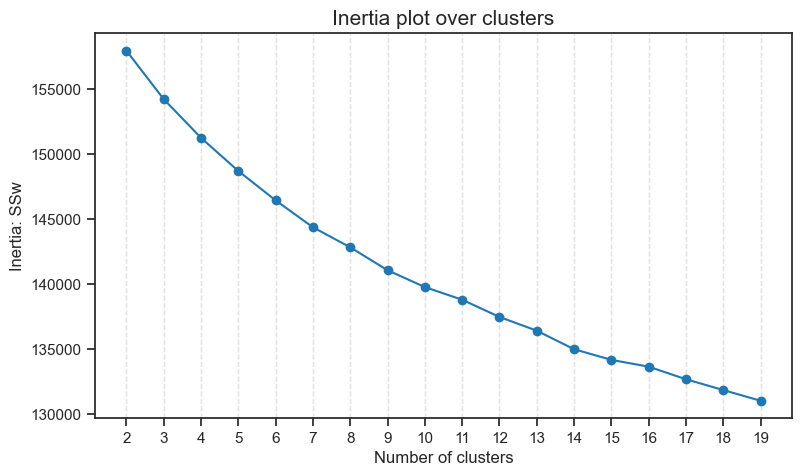

In [18]:
fig, ax = plt.subplots(figsize=(9,5))

range_clusters= list(range(2,20))
inertia= df_cluster_metrics['ssw (Lower is better, 0 to +∞)']
ax.plot(range_clusters, inertia, marker='o', zorder=2)
ax.set_xticks(list(range_clusters))

# draw vertical dashed background lines at each cluster number
for x in range_clusters:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=1, zorder=0, alpha=0.7)

ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [19]:
# final cluster solution
number_clusters = 14
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(df_for_modeling)
km_labels

array([13,  2, 11, ...,  2,  9,  7], dtype=int32)

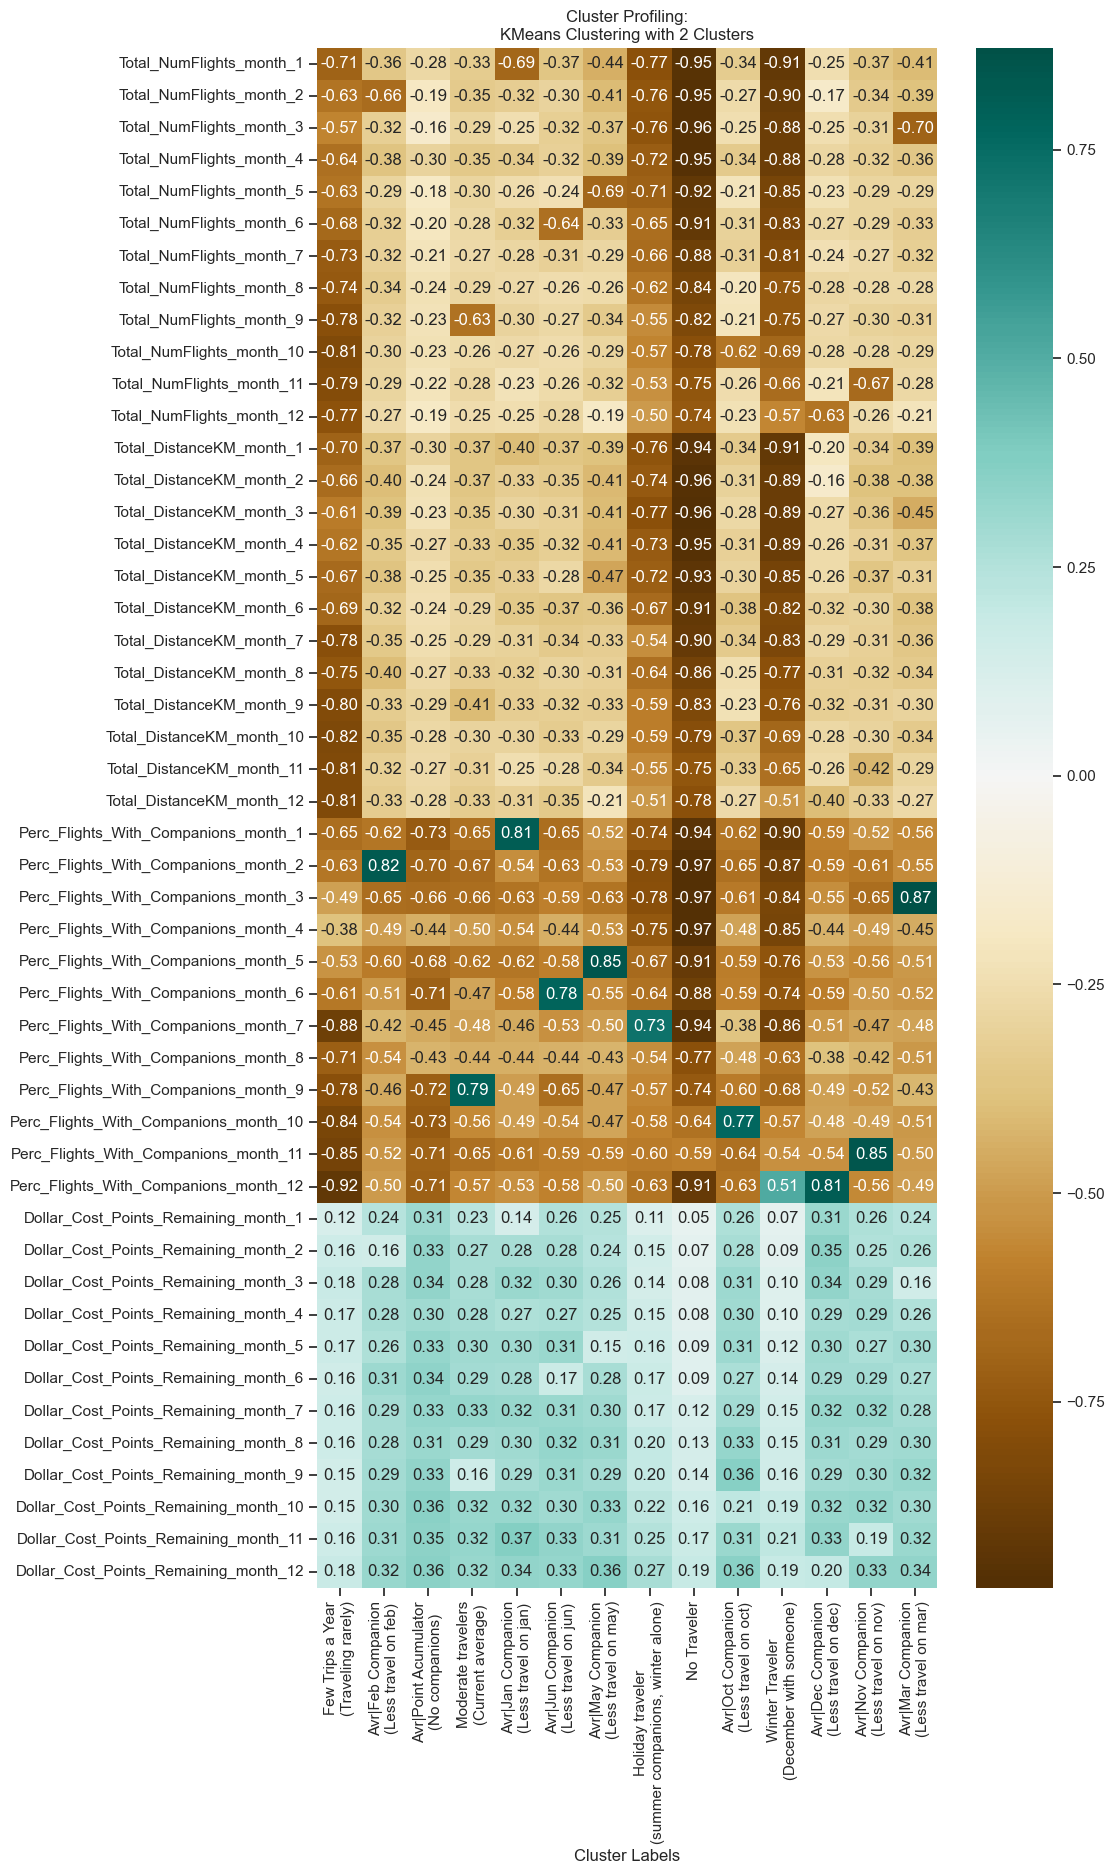

In [ ]:
cluster_name_map = {
    0: "Few Trips a Year\n(Traveling rarely)",
    1: "Avr|Feb Companion\n(Less travel on feb)",
    2: "Avr|Point Acumulator\n(No companions)",
    3: "Moderate travelers\n(Current average)",
    4: "Avr|Jan Companion\n(Less travel on jan)",
    5: "Avr|Jun Companion\n(Less travel on jun)",
    6: "Avr|May Companion\n(Less travel on may)",
    7: "Holiday traveler\n(summer companions, winter alone)",
    8: "No Traveler",
    9: "Avr|Oct Companion\n(Less travel on oct)",
    10: "Winter Traveler\n(December with someone)",
    11: "Avr|Dec Companion\n(Less travel on dec)",
    12: "Avr|Nov Companion\n(Less travel on nov)",
    13: "Avr|Mar Companion\n(Less travel on mar)",
}

# Characterizing the final clusters
df_concat_km = pd.concat((df_for_modeling, pd.Series(km_labels, name='labels', index=df_for_modeling.index)), axis=1)

fig, ax = plt.subplots(figsize=(10,20))

km_profile = df_concat_km.groupby('labels').mean().T

# Rename cluster columns using your mapping
km_profile = km_profile.rename(columns=cluster_name_map)

sns.heatmap(km_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 2 Clusters")
plt.show()

Average are point acumulators, that only used points when flying with companions

0- Few trips a year

1- Average with fewer trips on feb, but with companions on that month

2- Average, point acumulator

3- Average with fewer trips on sep, but with companions on that month

4- Average with fewer trips on jan, but with companions on that month

5- Average with fewer trips on jun, but with companions on that month

6- Average with fewer trips on may, but with companions on that month

7- Holiday traveler (summer with companions, winter alone)

8- No traveler

9- Average with fewer trips on oct, but with companions on that month

10-Only travel on december with someone

11- Average with fewer trips on dec, but with companions on that month

12- Average with fewer trips on nov, but with companions on that month

13- Average with fewer trips on mar, but with companions on that month

In [ ]:
df_concat_km['cluster_name'] = df_concat_km['labels'].map(cluster_name_map)

df_concat_km['cluster_name'].value_counts()

cluster_name
Avr|Point Acumulator\n(No companions)                  1895
No Traveler                                            1685
Avr|Mar Companion\n(Less travel on mar)                1145
Avr|May Companion\n(Less travel on may)                1092
Avr|Nov Companion\n(Less travel on nov)                1072
Avr|Feb Companion\n(Less travel on feb)                1066
Avr|Jan Companion\n(Less travel on jan)                1062
Avr|Jun Companion\n(Less travel on jun)                 988
Avr|Oct Companion\n(Less travel on oct)                 941
Moderate travelers\n(Current average)                   928
Avr|Dec Companion\n(Less travel on dec)                 925
Few Trips a Year\n(Traveling rarely)                    839
Winter Traveler\n(December with someone)                770
Holiday traveler\n(summer companions, winter alone)     693
Name: count, dtype: int64

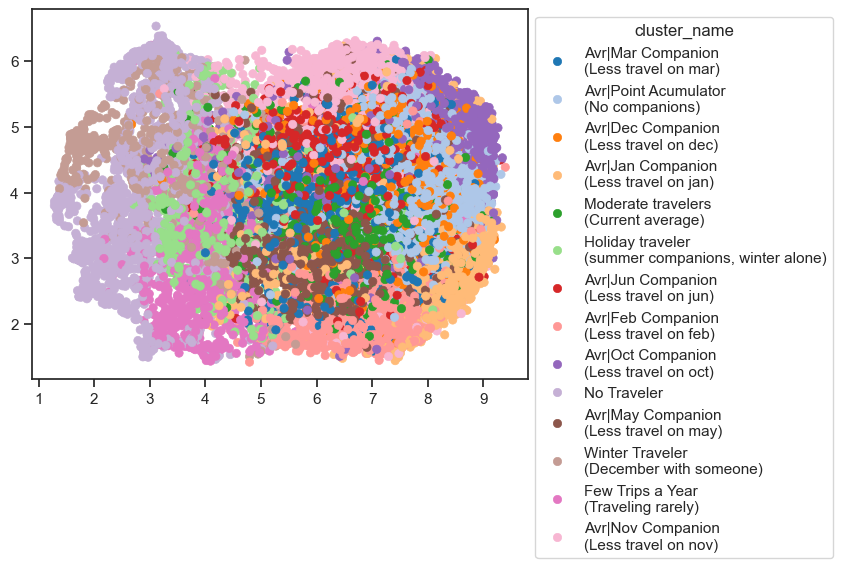

In [ ]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_km['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette = 'tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

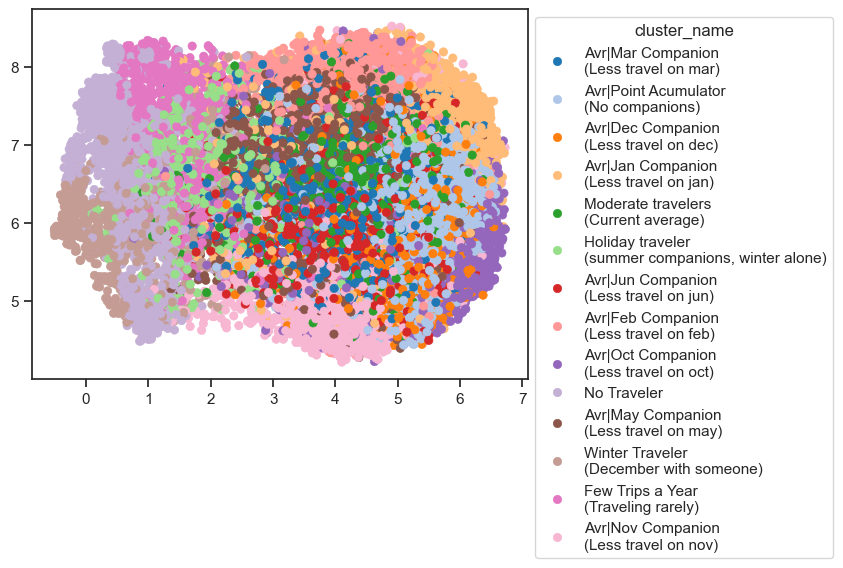

In [ ]:
umap_original = umap.UMAP(n_neighbors = 500, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_km['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette = 'tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

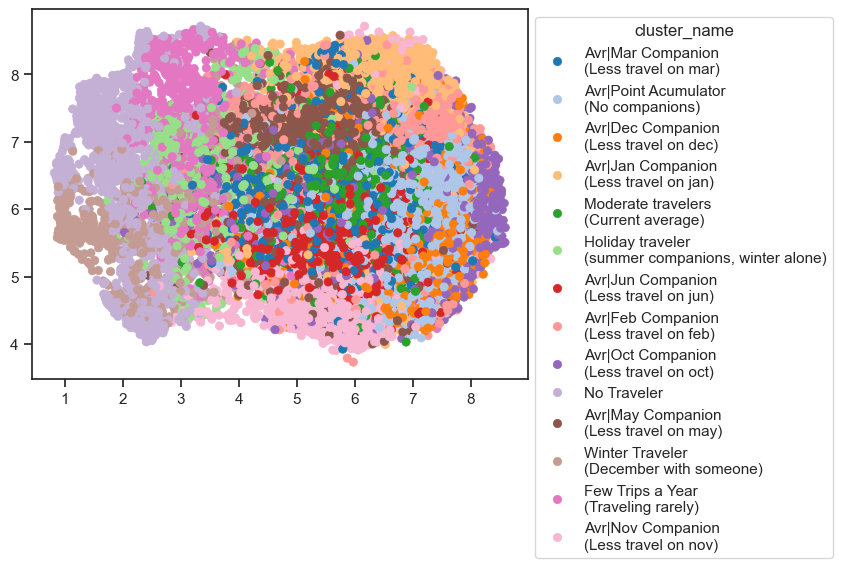

In [ ]:
umap_original = umap.UMAP(n_neighbors = 100, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_km['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette = 'tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

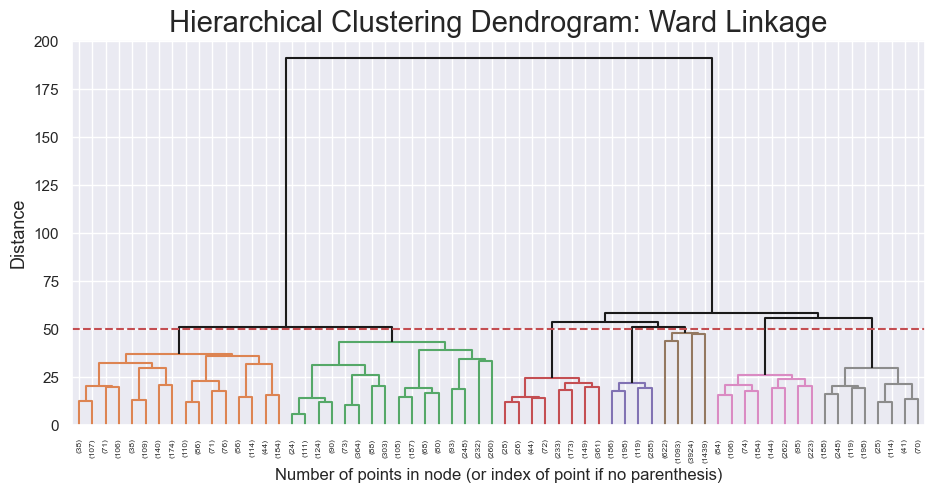

In [29]:
linkage_matrix= linkage(df_for_modeling, method="ward")

# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 50
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

In [30]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=7)
hc_labels = hclust.fit_predict(df_for_modeling)
hc_labels

array([4, 0, 0, ..., 0, 4, 1])

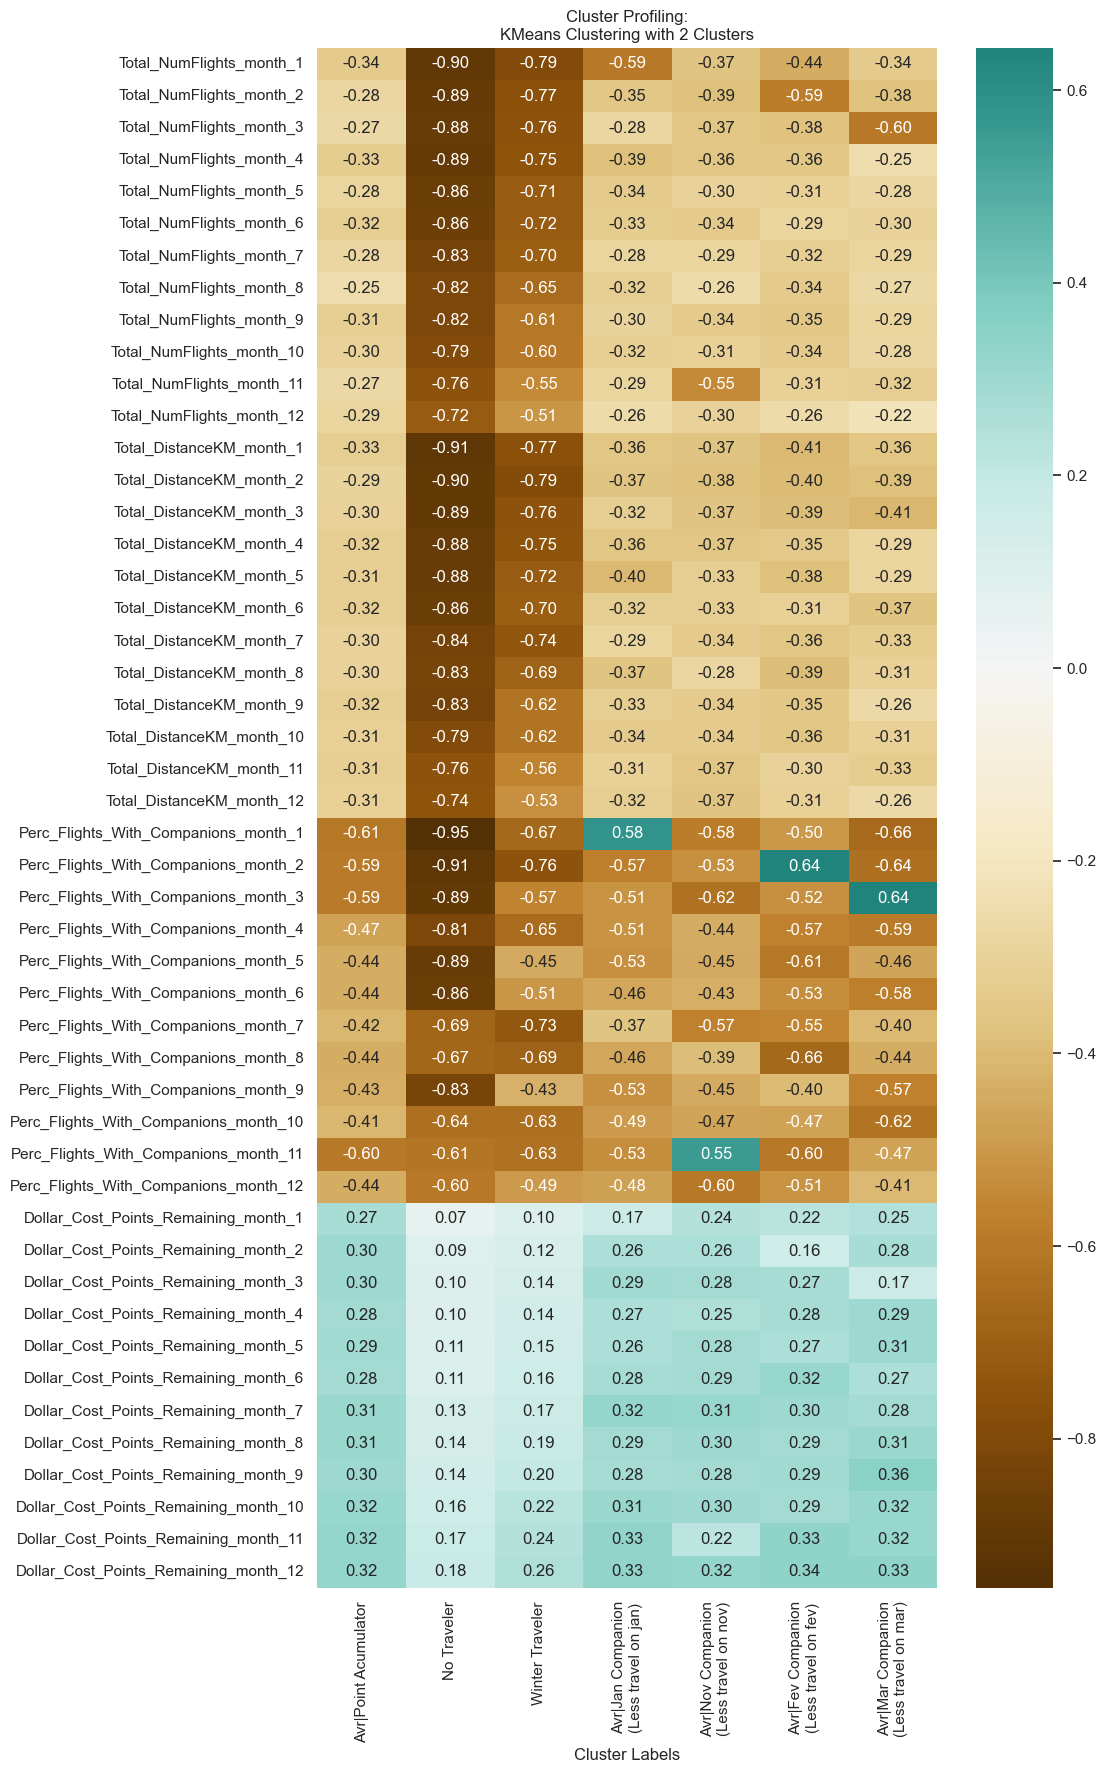

In [38]:
cluster_name_map = {
    0: "Avr|Point Acumulator",
    1: "No Traveler",
    2: "Winter Traveler",
    3: "Avr|Jan Companion\n(Less travel on jan)",
    4: "Avr|Nov Companion\n(Less travel on nov)",
    5: "Avr|Fev Companion\n(Less travel on fev)",
    6: "Avr|Mar Companion\n(Less travel on mar)"
}

# Characterizing the final clusters
df_concat_hc = pd.concat((df_for_modeling, pd.Series(hc_labels, name='labels', index=df_for_modeling.index)), axis=1)

fig, ax = plt.subplots(figsize=(10,20))

hc_profile = df_concat_hc.groupby('labels').mean().T

# Rename cluster columns using your mapping
hc_profile = hc_profile.rename(columns=cluster_name_map)

sns.heatmap(hc_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 2 Clusters")
plt.show()

In [34]:
#df_concat_hc['cluster_name'] = df_concat_hc['labels'].map(cluster_name_map)

df_concat_hc['labels'].value_counts()

labels
0    7078
1    2450
2    1524
3    1172
4    1086
5    1003
6     788
Name: count, dtype: int64

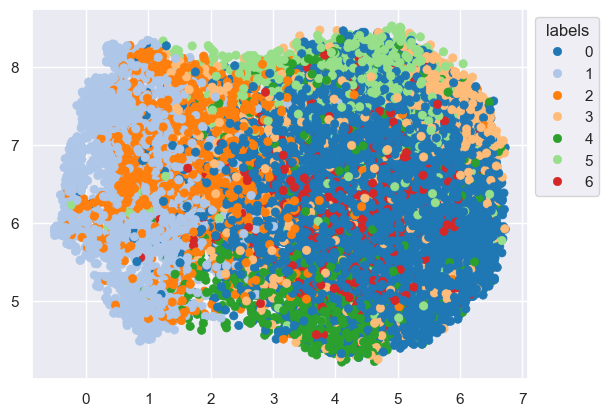

In [35]:
umap_original = umap.UMAP(n_neighbors = 500, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_hc['labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette = 'tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [37]:
# Compare metrics between KMeans and Hierarchical Clustering
df_kmeans_selection = df_cluster_metrics.iloc[[12]].copy()
df_kmeans_selection['Method'] = 'KMeans'


sil_hc = silhouette_score(X, hc_labels)

hc_row = pd.DataFrame([{
    'num_clusters': len(np.unique(hc_labels)),
    'ssw (Lower is better, 0 to +∞)': ssw,
    'ssb (Higher is better, 0 to SST)': ssb,
    'silhouette_score (Higher is better, −1 to +1)': sil_hc,
    'r2 (Higher is better, 0 to 1)': ssb / sst,
    'Method': 'Hierarchical'
}])

df_final_comparison = pd.concat([df_kmeans_selection, hc_row], ignore_index=True)

column_order = [
    'Method', 
    'num_clusters', 
    'r2 (Higher is better, 0 to 1)', 
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

df_final_comparison = df_final_comparison[column_order]
display(df_final_comparison)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,KMeans,14,0.242722,0.033037,134987.256948,43266.072207
1,Hierarchical,7,0.264975,0.016204,131020.663832,47232.613151


Both solutions are bad, we are going to test if reducing first the dimentionaly of the data and them apply some clusters.

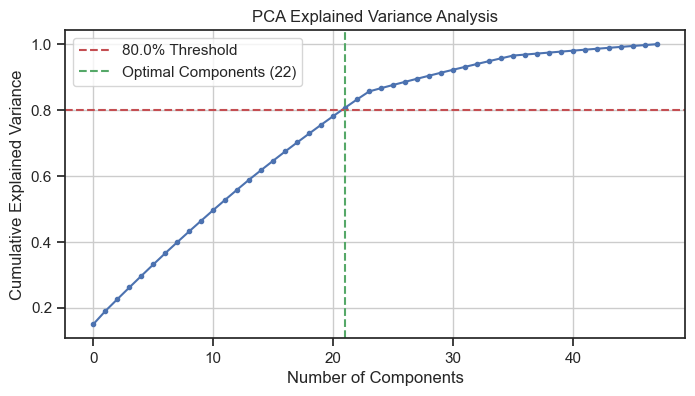

In [41]:
# Fit PCA to the scaled training data
pca = PCA()
pca.fit(df_for_modeling)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components for 95% variance
# argmax returns the first index where the condition is True
# We add 1 because indices start at 0
target_variance = 0.80
d_best = np.argmax(cumsum_variance >= target_variance) + 1

# Optional: Plotting variance explanation
plt.figure(figsize=(8, 4))
plt.plot(cumsum_variance, marker='.')
plt.axhline(y=target_variance, color='r', linestyle='--', label=f'{target_variance*100}% Threshold')
plt.axvline(x=d_best-1, color='g', linestyle='--', label=f'Optimal Components ({d_best})')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Analysis')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# interpret pc names
# create clusters based on PC (hierarquical an kmeans)
# caluclate scores
# conclude on final montlhy solution